In [2]:
import numpy as np
import matplotlib.pyplot as plt
import load_mnist

In [3]:
# load data using functions coded in load_mnist.py
y_train = load_mnist.load_labels(load_mnist.f_training_labels)
X_train = np.hstack((load_mnist.load_images(load_mnist.f_training_images)/255, 10*np.ones((len(y_train),1))))

y_test = load_mnist.load_labels(load_mnist.f_test_labels)
X_test = np.hstack((load_mnist.load_images(load_mnist.f_test_images)/255, 10*np.ones((len(y_test),1))))

In [4]:
def relu(_x):

    return np.maximum(0,_x)
              
def train_neuralnet(X, y, P, epochs, W_offset, V_offset):
    """Stochastic gradient descent algorithm for classifying handwritten digits
    
    Randomly selects n_batch records from the training data and processes as a minibatch. 
    
    P hidden nodes, 10 output nodes
    
    """
    
    ## convert the y vector, which contains actual digit labels to a matrix with a 0/1 for each digit
    y_train = load_mnist.digit_2_matrix(y)
        
    ## set initial weights randomly, a bias term is already included in X
    W = 0.001*(np.random.randn(len(X[0]), P)+W_offset)
    V = np.random.randn(P+1, 10)+V_offset
    
    ## may need to experiment with step size
    alpha = 1e-5
    
    ## perform stochastic gradient descent training
    for epoch in range(epochs):
        
        # random selection of training indices
        training_sample_index = np.random.permutation(len(X))
        
        for i in training_sample_index:        
                    
            # ReLU function with bias term added
            h = np.hstack((np.ones((1,1)), relu(X[[i],:]@W)))
            y_hat = relu(h@V)

            # Backpropagate
            delta = (y_hat-y_train[[i],:])*(y_hat>0)
            gamma = delta@V[1:,:].T*(h[:,1:]>0)
            
            V = V - alpha*h.T@delta
            W = W - alpha*X[[i],:].T@gamma
        
        # demonstrate the model error with the training data
        H = np.hstack((np.ones((len(X_train),1)), relu(X_train@W)))
        y_hat_digit = load_mnist.matrix_2_digit(H@V)

        err_train = 1 - np.sum(y_hat_digit==y) / len(y_train)
    
    return W, V

In [5]:
offset_range = np.arange(0,1,0.1)
neuron_count_range = np.array([20,40,60])
error = np.zeros((3, len(offset_range)))

for n, neuron_count in enumerate(neuron_count_range):
    
    for i, offset in enumerate(offset_range):

        for j in range(10):
            W, V = train_neuralnet(X_train, y_train, neuron_count, 1, offset, 0.5)

            # demonstrate the model error with the training data
            H = np.hstack((np.ones((len(X_train),1)), relu(X_train@W)))
            y_hat_digit = load_mnist.matrix_2_digit(H@V)

            error[n,i] += 1 - np.sum(y_hat_digit==y_train) / len(y_train)

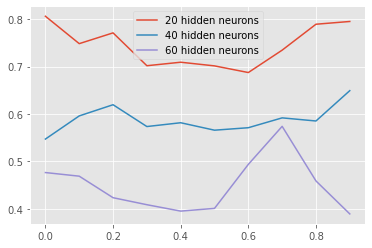

In [6]:
plt.plot(offset_range, error[0,:]/10, label='20 hidden neurons')
plt.plot(offset_range, error[1,:]/10, label='40 hidden neurons')
plt.plot(offset_range, error[2,:]/10, label='60 hidden neurons')
plt.legend()